Jupyter часть
 Подготовка данных
Скачать известный датасет Титаник (train и test)
Загрузить их как pandas.DataFrame
Корректно конкатенировать их в один DataFrame по ключу PassengerID. Отсутствующие данные должны быть Nan. Все столбцы должны быть корректных типов, в частности, выживание, класс и пол должны быть категориальными
 Анализ таблицы
Визуализировать базовую статистику таблицы. В каком классе было больше всего пассажиров?
Группировать таблицу в два уровня: класс и пол, по среднему значению возраста. Кто из возможных комбинаций самый юный, кто самый взрослый? Насколько отличаются эти значения?
Отобрать только выживших пассажиров с фамилией, начинающейся на “K”. Отсортировать их по убыванию стоимости билета. Кто заплатил больше всех? Кто меньше всех?
Какое максимальное количество родных было с выжившим пассажиром?

# Подготовка данных

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px


In [3]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [4]:
titanic_df = pd.concat([train_df, test_df], ignore_index=True)

# Анализ таблицы

In [5]:
titanic_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1305,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1306,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
1307,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [6]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 122.8+ KB


In [7]:
titanic_df['Survived'] = titanic_df['Survived'].astype('category')
titanic_df['Pclass'] = titanic_df['Pclass'].astype('category')
titanic_df['Sex'] = titanic_df['Sex'].astype('category')

In [8]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  1309 non-null   int64   
 1   Survived     891 non-null    category
 2   Pclass       1309 non-null   category
 3   Name         1309 non-null   object  
 4   Sex          1309 non-null   category
 5   Age          1046 non-null   float64 
 6   SibSp        1309 non-null   int64   
 7   Parch        1309 non-null   int64   
 8   Ticket       1309 non-null   object  
 9   Fare         1308 non-null   float64 
 10  Cabin        295 non-null    object  
 11  Embarked     1307 non-null   object  
dtypes: category(3), float64(2), int64(3), object(4)
memory usage: 96.4+ KB


,count
Pclass,
3,709
1,323
2,277


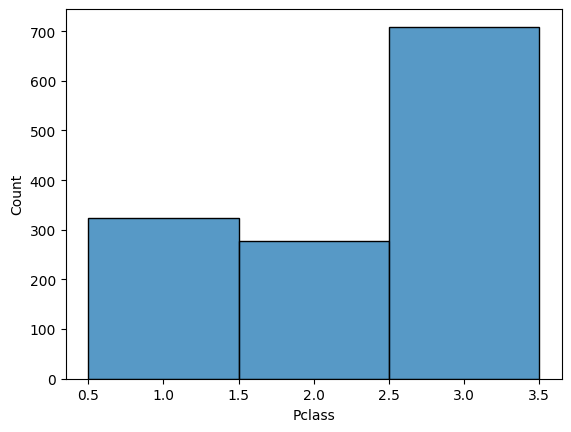

In [9]:
sns.histplot(titanic_df['Pclass'], bins=3)
titanic_df['Pclass'].value_counts()

# Ответ: в 3 классе было больше всего пассажиров

In [10]:
titanic_df.groupby(['Pclass', 'Sex'])['Age'].mean()

/tmp/ipython-input-3038187696.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic_df.groupby(['Pclass', 'Sex'])['Age'].mean()


Pclass  Sex   
1       female    37.037594
        male      41.029272
2       female    27.499223
        male      30.815380
3       female    22.185329
        male      25.962264
Name: Age, dtype: float64

# Ответ: самый юный женщины 3-го класса, самый взрослый мужчины 1-го класса. Эти значения отличаются на 18.84

In [13]:
survivers = titanic_df[titanic_df['Survived'] == 1]
k_surname = survivers[survivers['Name'].str.split(',').str[0].str.startswith('K')]
k_surname.sort_values('Fare', ascending=False)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
621,622,1.0,1,"Kimball, Mr. Edwin Nelson Jr",male,42.0,1,0,11753,52.5542,D19,S
457,458,1.0,1,"Kenyon, Mrs. Frederick R (Marion)",female,NaN,1,0,17464,51.8625,D21,S
316,317,1.0,2,"Kantor, Mrs. Sinai (Miriam Sternin)",female,24.0,1,0,244367,26.0000,NaN,S
184,185,1.0,3,"Kink-Heilmann, Miss. Luise Gretchen",female,4.0,0,2,315153,22.0250,NaN,S
706,707,1.0,2,"Kelly, Mrs. Florence ""Fannie""",female,45.0,0,0,223596,13.5000,NaN,S
691,692,1.0,3,"Karun, Miss. Manca",female,4.0,0,1,349256,13.4167,NaN,C
303,304,1.0,2,"Keane, Miss. Nora A",female,NaN,0,0,226593,12.3500,E101,Q
300,301,1.0,3,"Kelly, Miss. Anna Katherine ""Annie Kate""",female,NaN,0,0,9234,7.7500,NaN,Q
573,574,1.0,3,"Kelly, Miss. Mary",female,NaN,0,0,14312,7.7500,NaN,Q


# Ответ: заплатил больше всех Kimball, Mr. Edwin Nelson Jr, меньше всех Kelly, Miss. Mary

In [12]:
survivers['family_size'] = survivers['Parch'] + survivers['SibSp']

survivers['family_size'].max()

/tmp/ipython-input-3631854479.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  survivers['family_size'] = survivers['Parch'] + survivers['SibSp']


6

# Ответ: максимальное количество родных с выжившим пассажиром было 6.

# Визуализация

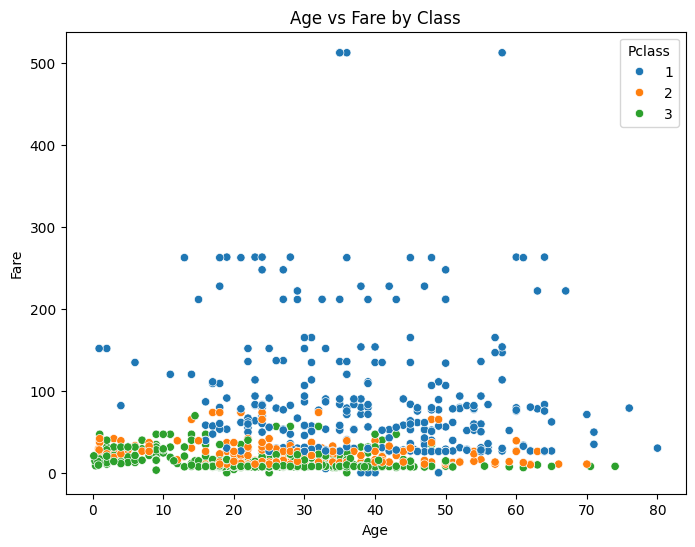

In [16]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=titanic_df, x='Age', y='Fare', hue='Pclass')
plt.title('Age vs Fare by Class')
plt.show()

/tmp/ipython-input-2285886376.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sns.lineplot(data=titanic_df.groupby('Pclass')[['Age','Fare']].mean().reset_index(), x='Pclass', y='Age', label='Средний возраст')
/tmp/ipython-input-2285886376.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sns.lineplot(data=titanic_df.groupby('Pclass')[['Age','Fare']].mean().reset_index(), x='Pclass', y='Fare', label='Средняя стоимость билета')


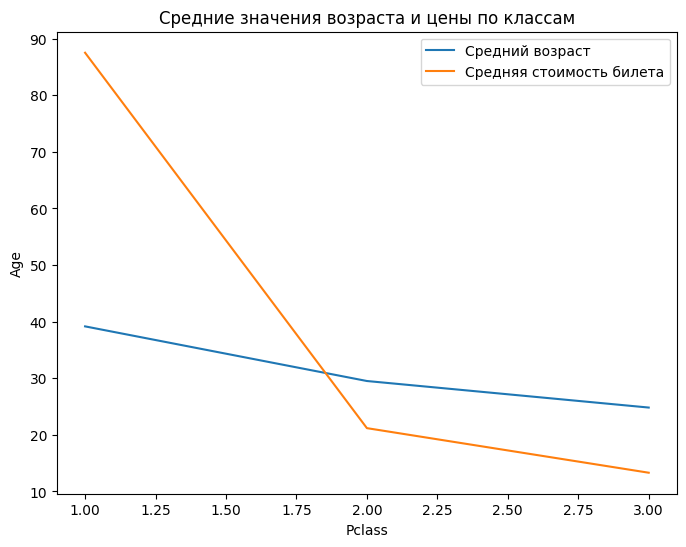

In [17]:
plt.figure(figsize=(8,6))
sns.lineplot(data=titanic_df.groupby('Pclass')[['Age','Fare']].mean().reset_index(), x='Pclass', y='Age', label='Средний возраст')
sns.lineplot(data=titanic_df.groupby('Pclass')[['Age','Fare']].mean().reset_index(), x='Pclass', y='Fare', label='Средняя стоимость билета')
plt.title('Средние значения возраста и цены по классам')
plt.legend()
plt.show()

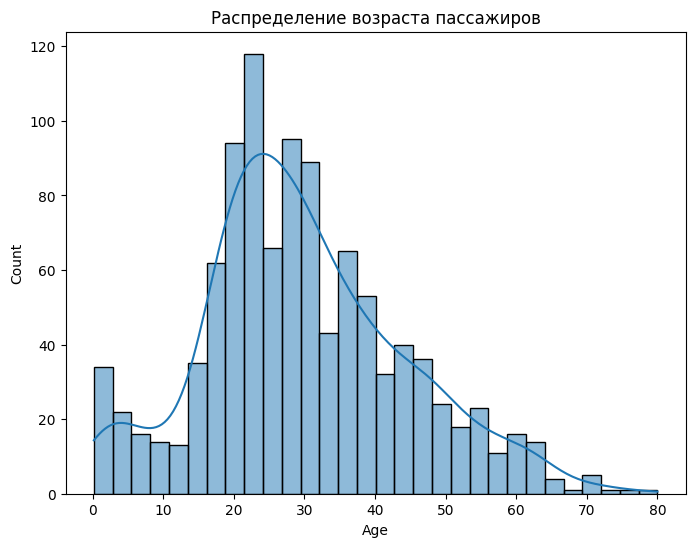

In [18]:
plt.figure(figsize=(8,6))
sns.histplot(titanic_df['Age'].dropna(), bins=30, kde=True)
plt.title('Распределение возраста пассажиров')
plt.show()

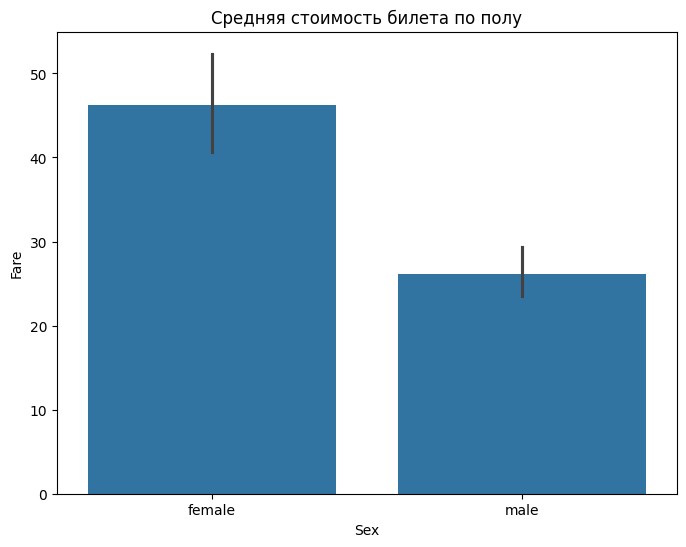

In [19]:
plt.figure(figsize=(8,6))
sns.barplot(data=titanic_df, x='Sex', y='Fare')
plt.title('Средняя стоимость билета по полу')
plt.show()

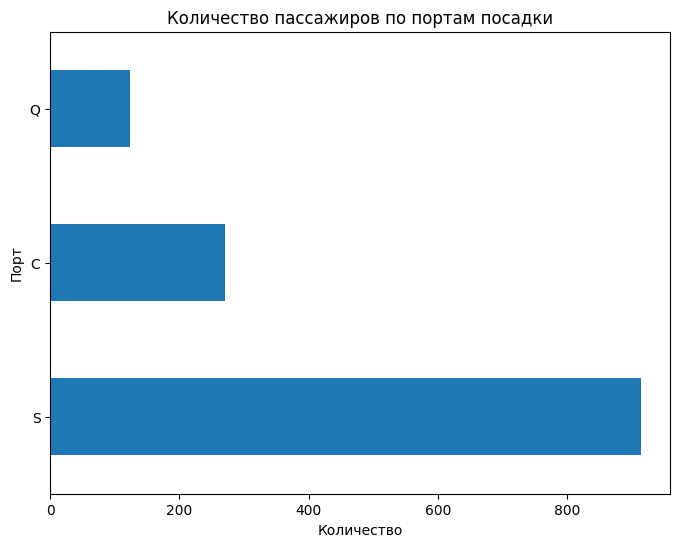

In [20]:
plt.figure(figsize=(8,6))
titanic_df['Embarked'].value_counts().plot(kind='barh')
plt.title('Количество пассажиров по портам посадки')
plt.xlabel('Количество')
plt.ylabel('Порт')
plt.show()

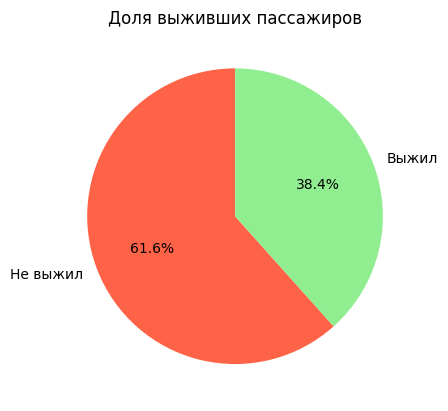

In [21]:
titanic_df['Survived'].value_counts().plot.pie(autopct='%1.1f%%', labels=['Не выжил', 'Выжил'], colors=['tomato','lightgreen'], startangle=90)
plt.title('Доля выживших пассажиров')
plt.ylabel('')
plt.show()

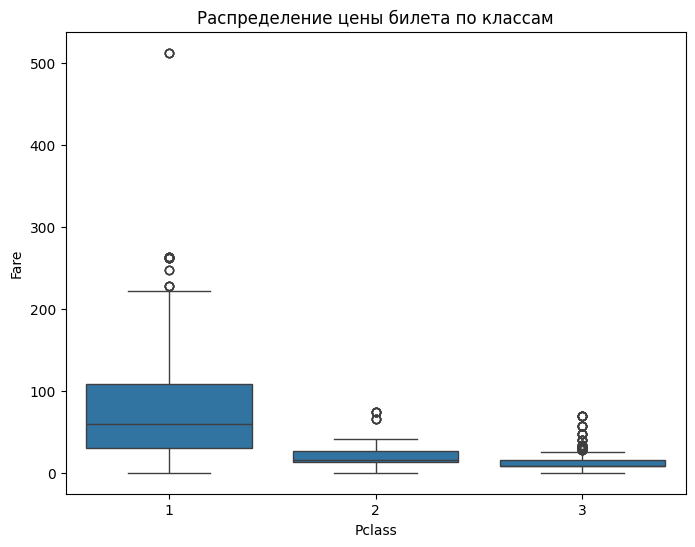

In [22]:
plt.figure(figsize=(8,6))
sns.boxplot(data=titanic_df, x='Pclass', y='Fare')
plt.title('Распределение цены билета по классам')
plt.show()

In [25]:
fig = px.sunburst(
    titanic_df.dropna(subset=['Survived']),
    path=['Pclass', 'Sex', 'Survived'],
    values='Fare',
    title='Распределение выживших по классам и полу'
)
fig.show()


/usr/local/lib/python3.12/dist-packages/plotly/express/_core.py:1727: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dfg = df.groupby(path[i:]).agg(agg_f)
/usr/local/lib/python3.12/dist-packages/plotly/express/_core.py:1727: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dfg = df.groupby(path[i:]).agg(agg_f)
/usr/local/lib/python3.12/dist-packages/plotly/express/_core.py:1727: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  

In [27]:
fig = px.scatter_3d(
    titanic_df.dropna(subset=['Age', 'Fare']),
    x='Age', y='Fare', z='Pclass',
    color='Sex',
    size='Fare',
    hover_data=['Name'],
    title='3D визуализация: Возраст, стоимость билета и класс пассажиров'
)
fig.show()


In [30]:
fig = px.box(titanic_df, x='Sex', y='Fare', color='Pclass', title='стоимость билета по полу и классу')
fig.show()

In [29]:
fig = px.bar(titanic_df, x='Embarked', y='Fare', color='Sex', title='Средняя стоимость билета по портам посадки и полу', barmode='group')
fig.show()

In [31]:
fig = px.scatter(titanic_df, x='Age', y='Fare', color='Sex', title='Интерактивный график')
fig.show()